In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("../data/raw/richmond.csv")

In [3]:
data["Date"] = pd.to_datetime(data["Date"])

data["TouristEvent"] = data["TouristEvent"].map({
    "No":0,
    "Yes":1
})

data = data.sort_values("Date")

In [4]:
features = [
    "Num_Employees",
    "Num_Customers",
    "Pct_On_Sale",
    "TouristEvent"
]

target = "Sales"

In [5]:
train_size = 100
forecast_horizon = 7

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

errors = []

for i in range(train_size, len(data) - forecast_horizon):

    train = data.iloc[:i]
    test = data.iloc[i:i+forecast_horizon]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    model = RandomForestRegressor()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    error = mean_absolute_error(y_test, preds)

    errors.append(error)

In [7]:
print("Average MAE:", np.mean(errors))

Average MAE: 3886.267168476616


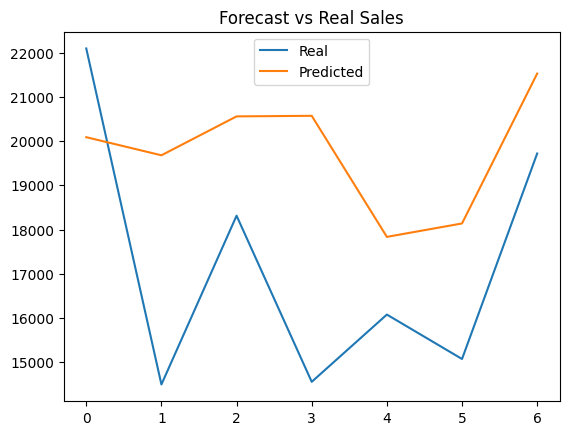

In [8]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label="Real")
plt.plot(preds, label="Predicted")

plt.legend()
plt.title("Forecast vs Real Sales")

plt.show()

In [9]:
stores = [
    "richmond",
    "baltimore",
    "lancaster",
    "philadelphia"
]

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

results = {}

for store in stores:

    print("Running backtesting for:", store)

    data = pd.read_csv(f"../data/raw/{store}.csv")

    data["Date"] = pd.to_datetime(data["Date"])

    data["TouristEvent"] = data["TouristEvent"].map({
        "No":0,
        "Yes":1
    })

    data = data.sort_values("Date")

    features = [
        "Num_Employees",
        "Num_Customers",
        "Pct_On_Sale",
        "TouristEvent"
    ]

    target = "Sales"

    train_size = 100
    forecast_horizon = 7

    errors = []

    for i in range(train_size, len(data) - forecast_horizon):

        train = data.iloc[:i]
        test = data.iloc[i:i+forecast_horizon]

        X_train = train[features]
        y_train = train[target]

        X_test = test[features]
        y_test = test[target]

        model = RandomForestRegressor()

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        error = mean_absolute_error(y_test, preds)

        errors.append(error)

    results[store] = np.mean(errors)

print("\nBacktesting Results:")
print(results)

Running backtesting for: richmond
Running backtesting for: baltimore
Running backtesting for: lancaster
Running backtesting for: philadelphia

Backtesting Results:
{'richmond': np.float64(3899.390973069294), 'baltimore': np.float64(7486.0230971993415), 'lancaster': np.float64(12173.123332548834), 'philadelphia': np.float64(11822.330891974583)}
